# EDA - ORL Balanced

Notebook nay chi doc bundle ORL da duoc split san de xem phan bo du lieu, anh mau truoc/sau split, va doi chieu test manifest.


In [5]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

if not (ROOT / "src").exists():
    raise RuntimeError("Could not locate repo root containing 'src'.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ROOT


WindowsPath('D:/ki2nam3/toanAI/math_for_ml')

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.process import load_processed_dataset_bundle_for_preset
from src.utils import plot_sample_images


In [7]:
config = {
    "dataset_name": "orl",
    "preset_name": "balanced",
    "n_samples": 10,
}

pd.Series(config)


dataset_name         orl
preset_name     balanced
n_samples             10
dtype: object

## Load Bundle


In [ ]:
from src.process import create_processed_dataset_bundle_for_preset

# try to create the processed bundle if it doesn't exist
try:
    bundle = load_processed_dataset_bundle_for_preset(
        dataset_name=config["dataset_name"],
        preset_name=config["preset_name"],
    )
except FileNotFoundError:
    # Create the bundle if it doesn't exist
    print(f"Creating processed dataset bundle for {config['dataset_name']}/{config['preset_name']}...")
    create_processed_dataset_bundle_for_preset(
        dataset_name=config["dataset_name"],
        preset_name=config["preset_name"],
    )
    bundle = load_processed_dataset_bundle_for_preset(
        dataset_name=config["dataset_name"],
        preset_name=config["preset_name"],
    )

summary = bundle["summary"]
image_shape = bundle["image_shape"]

pd.Series({
    "dataset_name": summary["dataset_name"],
    "samples_total": summary["samples_total"],
    "classes_total": summary["classes_total"],
    "train_shape": summary["train_shape"],
    "test_shape": summary["test_shape"],
    "processing_profile": summary.get("processing_profile"),
    "quality_gate": summary.get("quality_gate"),
    "bundle_dir": bundle["output_dir"],
    "test_manifest": str(Path(bundle["output_dir"]) / "manifest_test.csv"),
})


FileNotFoundError: Processed dataset bundle does not exist yet: D:\ki2nam3\toanAI\math_for_ml\data\processed\orl\min10_max10_size92x112_flat_balanced10
Processed dataset bundle is missing. Run the preprocessing/data-generation step for `orl/balanced` first (e.g. `src.process.create_processed_dataset_bundle_for_preset` or equivalent) then rerun this cell.

## Before Split


In [ ]:
all_counts = pd.Series(bundle["metadata"]["subject_names"], name="subject_name").value_counts().sort_index()
all_counts.describe()


count    40.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
Name: count, dtype: float64

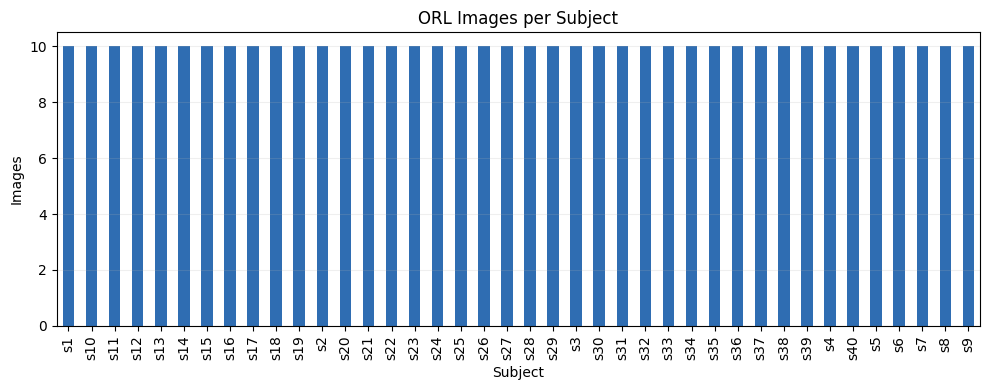

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
all_counts.plot(kind="bar", ax=ax, color="#2f6db2")
ax.set_title("ORL Images per Subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Images")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()


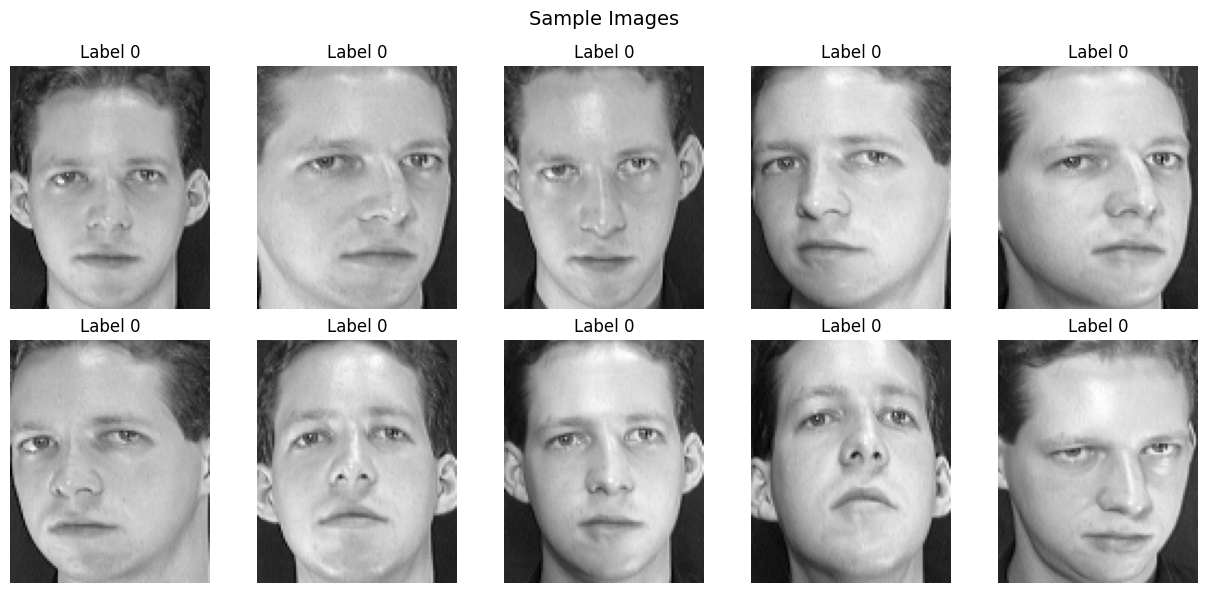

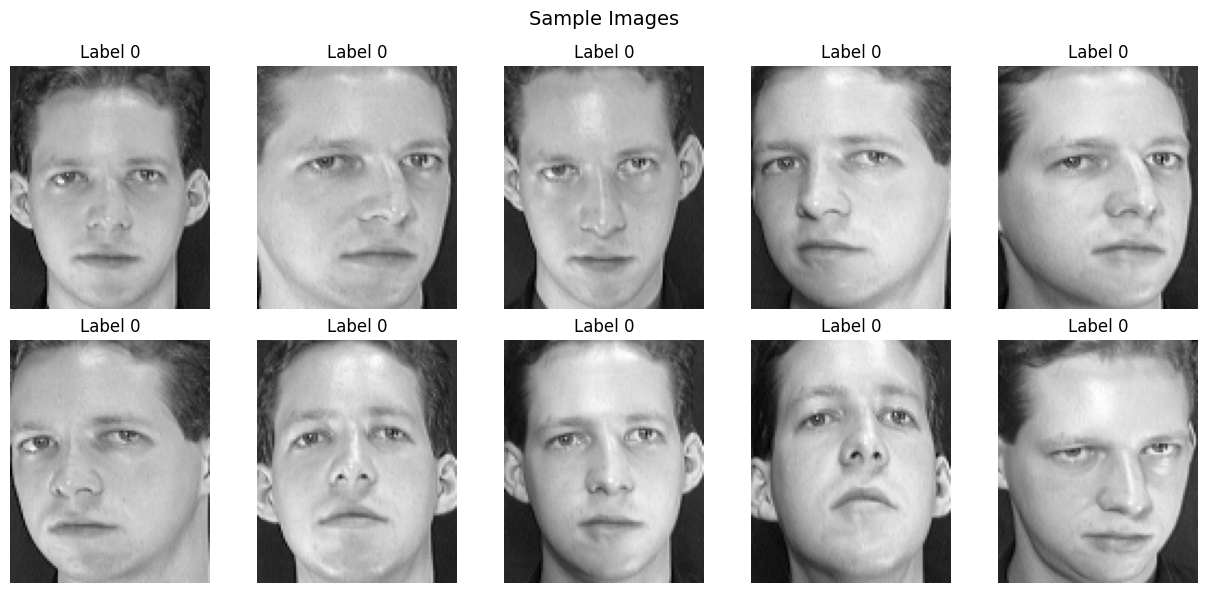

In [ ]:
plot_sample_images(
    bundle["X"],
    labels=bundle["y"],
    image_shape=image_shape,
    n_samples=config["n_samples"],
)


## After Split


In [ ]:
train_counts = pd.Series(bundle["train_metadata"]["subject_names"], name="train").value_counts().sort_index()
test_counts = pd.Series(bundle["test_metadata"]["subject_names"], name="test").value_counts().sort_index()
split_counts = pd.concat([train_counts, test_counts], axis=1)
split_counts.head(20)


,count,count
s1,8,2
s10,8,2
s11,8,2
s12,8,2
s13,8,2
s14,8,2
s15,8,2
s16,8,2
s17,8,2
s18,8,2


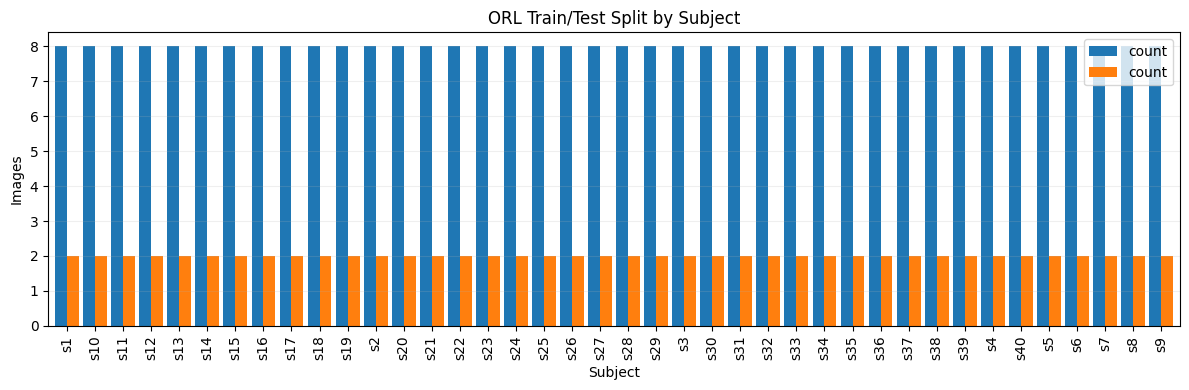

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
split_counts.plot(kind="bar", ax=ax, width=0.85)
ax.set_title("ORL Train/Test Split by Subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Images")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()


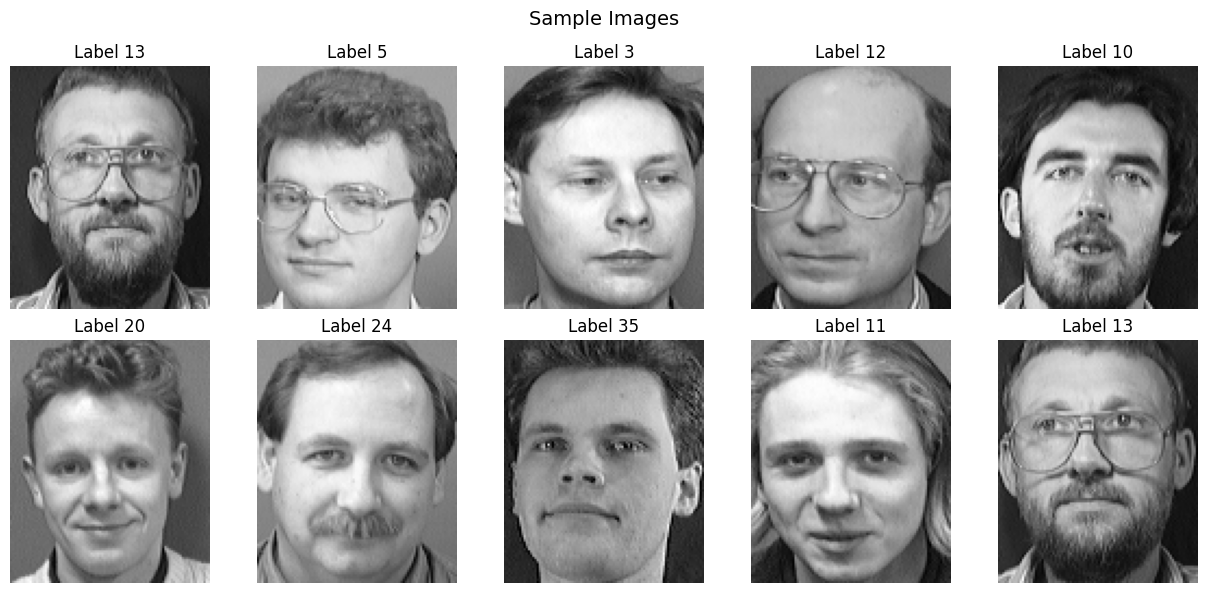

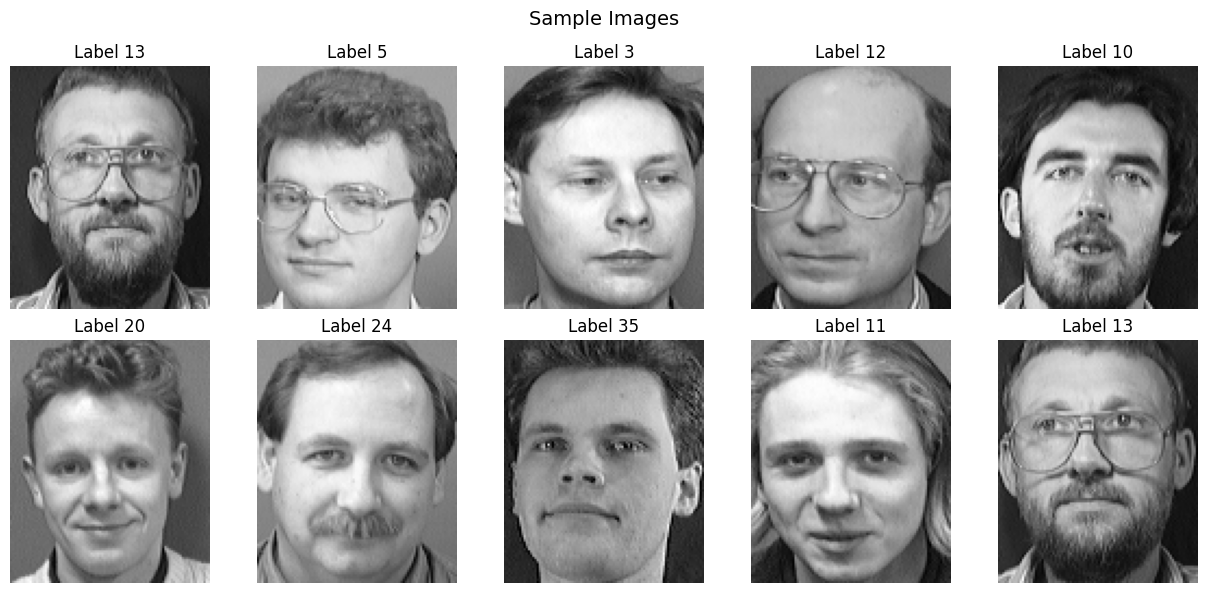

In [ ]:
plot_sample_images(
    bundle["X_train"],
    labels=bundle["y_train"],
    image_shape=image_shape,
    n_samples=config["n_samples"],
)


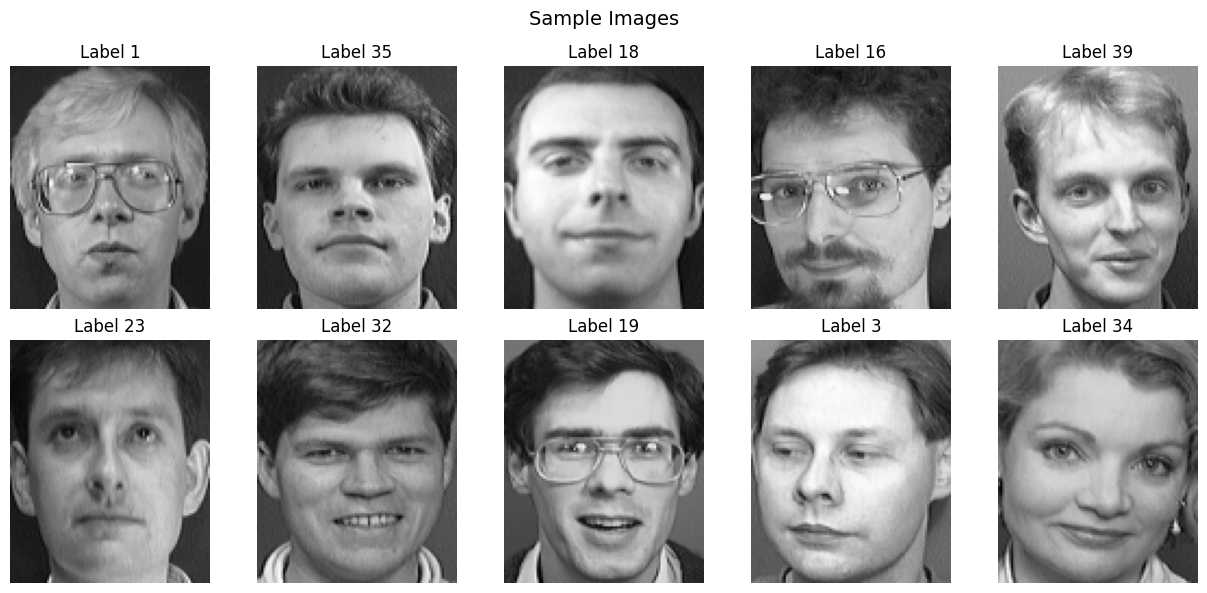

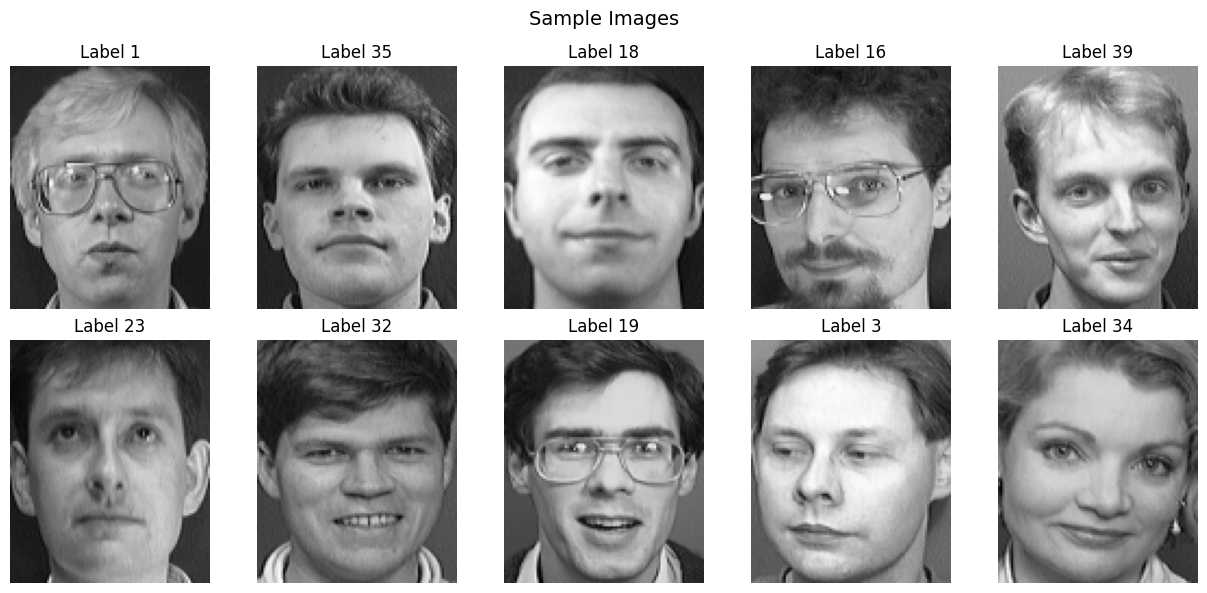

In [ ]:
plot_sample_images(
    bundle["X_test"],
    labels=bundle["y_test"],
    image_shape=image_shape,
    n_samples=config["n_samples"],
)


## Test Manifest Preview


In [ ]:
pd.DataFrame({
    "test_file_path": bundle["test_file_paths"][:10],
    "test_subject": bundle["test_metadata"]["subject_names"][:10],
    "test_label": bundle["y_test"][:10],
})


,test_file_path,test_subject,test_label
0,data\raw\ORL\s2\3.pgm,s2,1
1,data\raw\ORL\s36\3.pgm,s36,35
2,data\raw\ORL\s19\4.pgm,s19,18
3,data\raw\ORL\s17\7.pgm,s17,16
4,data\raw\ORL\s40\1.pgm,s40,39
5,data\raw\ORL\s24\4.pgm,s24,23
6,data\raw\ORL\s33\5.pgm,s33,32
7,data\raw\ORL\s20\5.pgm,s20,19
8,data\raw\ORL\s4\6.pgm,s4,3
9,data\raw\ORL\s35\6.pgm,s35,34
